# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [4]:
# Завантажую дані
df = pd.read_csv('//content/drive/MyDrive/Analytics_HW/House_Rent_Dataset.csv', sep=None, engine='python')

# Дивлюсь розмір датасету
df.shape

(4746, 12)

In [5]:
# Перші 5 рядків
df.head(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [6]:
# Загальна інформація про дані
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [7]:
# Кількість пропущених значень
missing_values = df.isnull().sum()

# Відсоток
missing_percent = (missing_values / len(df)) * 100

# Об'єдную в таблицю
missing_df = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percent': missing_percent
})

missing_df

,missing_count,missing_percent
Posted On,0,0.0
BHK,0,0.0
Rent,0,0.0
Size,0,0.0
Floor,0,0.0
Area Type,0,0.0
Area Locality,0,0.0
City,0,0.0
Furnishing Status,0,0.0
Tenant Preferred,0,0.0


Пропущені значення відсутні, додаткова обробка не потрібна.

In [8]:
# Базова статистика
df.describe().round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


In [9]:
# Аналіз цільової змінної Rent
fig = px.histogram(df, x='Rent', nbins=50, title='Distribution of Rent')
fig.show()

Розподіл Rent є асиметричним з правим хвостом, і це означає, що можливі викиди.

In [10]:
# Робота з викидами
df['Rent_log'] = np.log1p(df['Rent'])

px.histogram(df, x='Rent_log', nbins=50, title='Log Distribution of Rent')

In [11]:
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Фільтруємо
df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)]

df_clean.shape

(4226, 13)

In [12]:
print("До:", df.shape)
print("Після:", df_clean.shape)

До: (4746, 13)
Після: (4226, 13)


Було видалено 520 записів з аномально високою/низькою орендою.

In [13]:
# Цільова змінна Rent після видалення викидів
px.histogram(df_clean, x='Rent', nbins=50, title='Rent after outlier removal')

In [14]:
# Аналіз категоріальних змінних
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Posted On: 81 unique values
Floor: 480 unique values
Area Type: 3 unique values
Area Locality: 2235 unique values
City: 6 unique values
Furnishing Status: 3 unique values
Tenant Preferred: 3 unique values
Point of Contact: 3 unique values


Категоріальні змінні мають різну кардинальність.
Змінні з низькою кардинальністю (City, Furnishing Status, Tenant Preferred тощо) підходять для One-Hot Encoding.
Змінні з високою кардинальністю (Area Locality, Floor) потребують додаткової обробки, оскільки можуть призвести до переобучення моделі.
Колонка Posted On буде перетворена у формат datetime з подальшим виділенням ознак.


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [15]:
# Обчислення матриці кореляції для числових змінних
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr()
corr_matrix


,BHK,Rent,Size,Bathroom,Rent_log
BHK,1.000000,0.401268,0.698453,0.747918,0.464757
Rent,0.401268,1.000000,0.393605,0.506528,0.936697
Size,0.698453,0.393605,1.000000,0.680607,0.446812
Bathroom,0.747918,0.506528,0.680607,1.000000,0.561427
Rent_log,0.464757,0.936697,0.446812,0.561427,1.000000


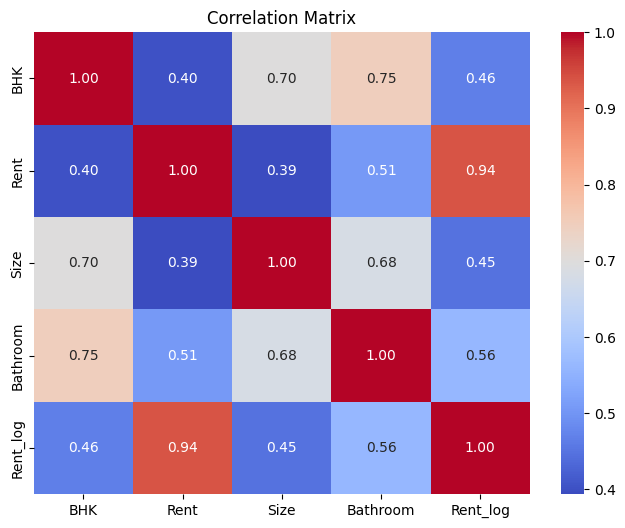

In [16]:
# Візуалізація з heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Найсильніший зв'язок із цільовою змінною Rent має Size, що логічно, оскільки більша площа → вища оренда.

In [17]:
 # Побудова Scatter plot між Size та Rent
 px.scatter(df_clean, x='Size', y='Rent', opacity=0.5)

Між Size та Rent спостерігається позитивна залежність, однак присутній значний розкид, що може свідчити про вплив інших факторів.

In [18]:
# Аналіз BHK та Rent за допомогою boxplot
px.box(df_clean, x='BHK', y='Rent')

Аналіз boxplot показує, що зі збільшенням кількості кімнат (BHK) зростає рівень орендної плати.
Медіана орендної плати збільшується разом із BHK, що свідчить про сильний позитивний зв'язок.
Водночас спостерігається зростання варіативності для більших значень BHK, що може вказувати на вплив додаткових факторів, таких як локація або рівень оснащення. Це підтверджується чисельно:

In [19]:
df_clean.groupby('BHK')['Rent'].median()

,Rent
BHK,
1,9000.0
2,14000.0
3,25000.0
4,35000.0
5,45000.0
6,32500.0


## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [20]:
# One-Hot Encoding тільки для потрібних колонок
cols_to_encode = [
    'Area Type',
    'City',
    'Furnishing Status',
    'Tenant Preferred',
    'Point of Contact'
]

df_encoded = pd.get_dummies(df_clean, columns=cols_to_encode, drop_first=True)

In [21]:
# Видаляю те, що не буде додано в модель
df_encoded = df_encoded.drop(columns=['Area Locality', 'Floor'])

In [22]:
# Формую X та y
X = df_encoded.drop(columns=['Rent'])
y = df_encoded['Rent']

In [23]:
# Стандартизую
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [24]:
# Перевірка
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4226 entries, 0 to 4745
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Posted On                          4226 non-null   object 
 1   BHK                                4226 non-null   float64
 2   Size                               4226 non-null   float64
 3   Bathroom                           4226 non-null   float64
 4   Rent_log                           4226 non-null   float64
 5   Area Type_Carpet Area              4226 non-null   bool   
 6   Area Type_Super Area               4226 non-null   bool   
 7   City_Chennai                       4226 non-null   bool   
 8   City_Delhi                         4226 non-null   bool   
 9   City_Hyderabad                     4226 non-null   bool   
 10  City_Kolkata                       4226 non-null   bool   
 11  City_Mumbai                        4226 non-null   bool   
 1

Для кодування були використані категоріальні змінні з низькою кардинальністю.
Змінні Area Locality та Floor не були включені до моделі через велику кількість унікальних значень та складну структуру відповідно.
Дані були підготовлені без додаткової трансформації цих колонок, щоб уникнути ускладнення моделі.

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [ ]:
# Posted On перетворюю в числа
df_encoded['Posted On'] = pd.to_datetime(df_encoded['Posted On'])

df_encoded['month'] = df_encoded['Posted On'].dt.month
df_encoded['year'] = df_encoded['Posted On'].dt.year

df_encoded = df_encoded.drop(columns=['Posted On'])

In [ ]:
# Видаляю Rent
X = df_encoded.drop(columns=['Rent'])

In [35]:
X = df_encoded.drop(columns=['Rent', 'Rent_log'])
y = df_encoded['Rent']

In [36]:
# Train / Test split (80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
# Створення моделі
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [38]:
# Навчання моделі
model.fit(X_train, y_train)

LinearRegression()

In [39]:
# Коєфіцієнт моделі
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(by='Coefficient', key=abs, ascending=False)

coefficients.head(10)

,Feature,Coefficient
9,City_Mumbai,18563.566364
15,Point of Contact_Contact Owner,-8636.843235
14,Point of Contact_Contact Builder,-5811.849032
11,Furnishing Status_Unfurnished,-4544.096964
0,BHK,3521.854280
10,Furnishing Status_Semi-Furnished,-3404.967647
8,City_Kolkata,-3252.281946
2,Bathroom,2550.441555
4,Area Type_Super Area,-2528.141688
7,City_Hyderabad,-2442.211277


In [40]:
# Знаходимо 2 найважливіші ознаки
top_features = coefficients.head(2)
top_features

,Feature,Coefficient
9,City_Mumbai,18563.566364
15,Point of Contact_Contact Owner,-8636.843235


Найбільший вплив на прогноз орендної плати мають змінні, пов’язані з локацією та типом контакту.
Зокрема, наявність квартири в місті Mumbai значно підвищує прогнозовану вартість оренди, тоді як контакт безпосередньо з власником асоціюється зі зниженням ціни.
Це свідчить про важливість географічного фактору та умов взаємодії при формуванні вартості оренди.

In [41]:
# Прогнози
y_train_pred = model.predict(X_train)

In [42]:
y_test_pred = model.predict(X_test)

In [43]:
pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_test_pred[:10]
})

,Actual,Predicted
0,22000,28527.400733
1,5000,3494.041141
2,37000,40081.884400
3,8000,2766.593351
4,15000,15157.559851
5,20000,23913.764309
6,8500,17482.806621
7,7000,3892.504514
8,3000,271.230098
9,8000,5943.102382


In [44]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, y_test_pred)

5534.118779500578

Модель лінійної регресії була навчена на підготовлених даних та використана для прогнозування орендної плати.
Середня абсолютна помилка (MAE) становить приблизно 5500, що складає близько 15% від середнього значення орендної плати.
Модель добре вловлює загальну тенденцію, однак має значні помилки для окремих спостережень, що може бути пов’язано з відсутністю важливих ознак, таких як детальна локація або поверх.

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [46]:
# Обчислюємо MAE, RMSE, R2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Test
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

print("TRAIN:")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

print("\nTEST:")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)

TRAIN:
MAE: 5543.609584774834
RMSE: 7694.990169461041
R2: 0.6898465947273125

TEST:
MAE: 5534.118779500578
RMSE: 7729.84039802357
R2: 0.6883802808648167


Значення метрик на тренувальній та тестовій вибірках є близькими, що свідчить про відсутність значного перенавчання.
Модель демонструє помірну точність прогнозування, однак значення помилки залишаються досить високими, що може вказувати на недонавчання або недостатню кількість інформативних ознак.

In [47]:
# Scatter plot (Actual vs Predicted)
fig = px.scatter(
    x=y_test,
    y=y_test_pred,
    labels={'x': 'Actual', 'y': 'Predicted'},
    title='Actual vs Predicted Rent'
)

fig.show()

In [48]:
# В цій візуалізації вирішила додати лінію ідеалу, щоб більш точно оцінити розкид точок
fig.add_scatter(
    x=y_test,
    y=y_test,
    mode='lines',
    name='Ideal'
)

fig.show()

Графік розсіювання показує, що модель загалом вловлює залежність між реальними та прогнозованими значеннями, однак спостерігається значний розкид точок відносно ідеальної лінії. Це свідчить про наявність помилок прогнозування, особливо для крайніх значень.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [49]:
# Обчилюю помилки
residuals = y_test - y_test_pred

In [58]:
# Гістограма розподілу помилок
fig = px.histogram(
    x=residuals,
    nbins=50,
    title='Distribution of Residuals',
    labels={'x': 'Errors (real - predicted)', 'count': 'count'},
    color_discrete_sequence=['#e74c3c']
)
fig.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Perfect Predict")
fig.update_layout(height=400)
fig.show()

In [59]:
# Scatter plot: помилки vs прогнозовані значення
fig = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Dependence of errors on predicted values',
    labels={'x': 'Predicted', 'y': 'Errors'},
    opacity=0.5
)

# Додаємо горизонтальну лінію на 0
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Without error")

fig.update_layout(height=400)
fig.show()

Аналіз графіка показує, що розкид помилок збільшується разом зі зростанням прогнозованого значення. Це свідчить про наявність гетероскедастичності, тобто залежності дисперсії помилок від величини прогнозу.

In [52]:
# 5 прогнозів з найбільшими помилками
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Residual': residuals
})

errors_df['Abs_Error'] = abs(errors_df['Residual'])

top_errors = errors_df.sort_values(by='Abs_Error', ascending=False).head(5)

top_errors

,Actual,Predicted,Residual,Abs_Error
3962,65000,32069.914461,32930.085539,32930.085539
549,8000,40102.178711,-32102.178711,32102.178711
904,8000,38166.196879,-30166.196879,30166.196879
3520,65000,35084.310228,29915.689772,29915.689772
275,30000,59705.850521,-29705.850521,29705.850521


In [53]:
# Додаю фічі назад
errors_df = errors_df.join(X_test)

In [54]:
# Аналізую по BHK
errors_df.groupby('BHK')['Abs_Error'].mean()

,Abs_Error
BHK,
1,4465.906009
2,5029.790894
3,7880.083987
4,12047.571656
5,4723.617574
6,5395.268697


Аналіз помилок показав, що модель має більші похибки для квартир з високою вартістю та більшою кількістю кімнат.
Також помилки можуть залежати від локації, що свідчить про недостатню деталізацію ознак, пов’язаних з місцем розташування